Shape: (2930, 82)
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  Sa

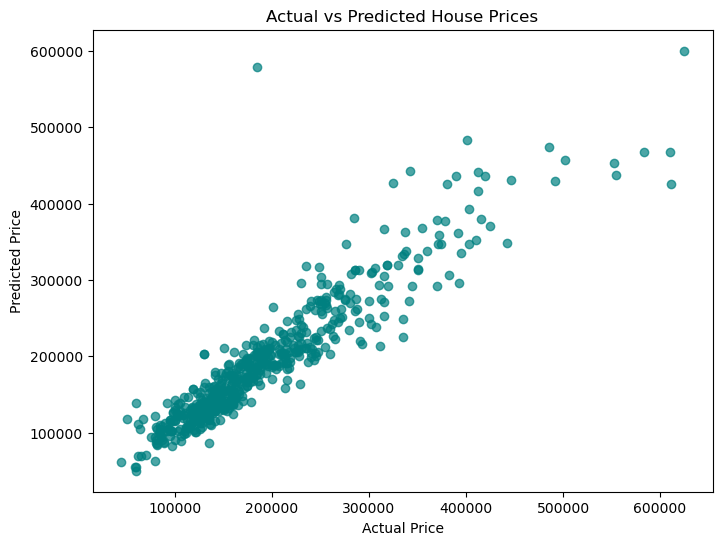

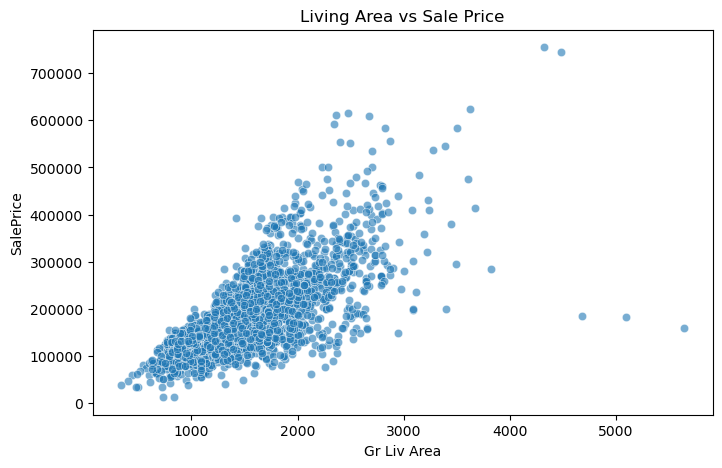

In [19]:
# Task 6: House Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Public Ames Housing dataset
url = "https://raw.githubusercontent.com/STATCowboy/pbidataflowstalk/master/AmesHousing.csv"
df = pd.read_csv(url)

# Save as Excel
df.to_excel("house_price_dataset.xlsx", index=False)

print("Shape:", df.shape)
print(df.head())

# Select a practical subset of features
features = [
    "Gr Liv Area",      # square footage
    "Bedroom AbvGr",    # bedrooms
    "Neighborhood",     # location
    "Full Bath",
    "Garage Cars",
    "Overall Qual",
    "Year Built"
]

target = "SalePrice"

data = df[features + [target]].copy()

# Handle missing values
data = data.dropna(subset=[target])

X = data[features]
y = data[target]

numeric_features = ["Gr Liv Area", "Bedroom AbvGr", "Full Bath", "Garage Cars", "Overall Qual", "Year Built"]
categorical_features = ["Neighborhood"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="teal")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Optional: feature relationship visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Gr Liv Area", y="SalePrice", alpha=0.6)
plt.title("Living Area vs Sale Price")
plt.show()